# 🌳 Árbol de Decisión — Regresión del Rendimiento Académico

Análisis comparativo y sistemático usando `DecisionTreeRegressor` entrenado con tres particiones distintas (80/20, 70/30, 60/40) para demostrar la robustez del modelo predictivo.

**Variable predictora (X):** `hours` — horas de estudio diarias
**Variable objetivo (Y):** `grade` — nota final (escala 1.0 – 5.0)

> **Pipeline ETL Educación** — datos sintéticos de 2 000 estudiantes distribuidos en 5 instituciones colombianas, almacenados en PostgreSQL (`educacion_db`). Replica la metodología del notebook climático aplicada al dataset académico.


## I. Configuración Inicial — Importaciones y Estilo Visual

In [1]:
# ── CELDA 1: Importaciones y bootstrap del path ──────────────────────────────
import sys, os

# Apuntar al subproyecto `Regresión Lineal/educacion/` para reutilizar
# scripts.database.engine (conexión a la BD educacion_db en PostgreSQL).
EDUCACION_DIR = os.path.abspath(os.path.join('..', '..', 'Regresión Lineal', 'educacion'))
if EDUCACION_DIR not in sys.path:
    sys.path.insert(0, EDUCACION_DIR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from scripts.database import engine

# Estilo visual consistente con los demás notebooks
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")
print(f"\n📂 educacion path: {EDUCACION_DIR}")


✅ Librerías importadas correctamente
   pandas  3.0.2
   numpy   2.4.4
   seaborn 0.13.2

📂 educacion path: C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion


## II. Carga de Datos desde PostgreSQL

Consultamos las tablas `registros_estudiantes` y `instituciones` con un JOIN.
Para esta regresión simple sólo usamos `hours` (X) y `grade` (Y), paralelo al notebook climático.


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
    r.hours,
    r.grade
FROM registros_estudiantes r
JOIN instituciones i ON r.institucion_id = i.id
ORDER BY r.fecha_registro
"""

df = pd.read_sql(QUERY, engine)

# Renombrar columnas para coincidir con la convención del prompt
df.rename(columns={
    'hours': 'Hours',
    'grade': 'Grade',
}, inplace=True)

print(f"✅ Datos cargados desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Valores nulos:")
print(df.isnull().sum())
print(f"\n📋 Primeras filas:")
df.head()


✅ Datos cargados desde PostgreSQL
   Filas    : 2,000
   Columnas : 2

📋 Valores nulos:
Hours    0
Grade    0
dtype: int64

📋 Primeras filas:


,Hours,Grade
0,4.9,2.99
1,5.0,3.10
2,2.6,1.48
3,2.4,2.27
4,2.6,2.53


In [3]:
# ── CELDA 3: Preparar vectores X / Y ─────────────────────────
X = df[['Hours']].values
y = df['Grade'].values

print(f"X shape: {X.shape}  (variable predictora: Hours — horas de estudio)")
print(f"y shape: {y.shape}  (variable objetivo:   Grade — nota final)")
print(f"\n📊 Estadísticas descriptivas:")
df.describe().round(2)


X shape: (2000, 1)  (variable predictora: Hours — horas de estudio)
y shape: (2000,)  (variable objetivo:   Grade — nota final)

📊 Estadísticas descriptivas:


,Hours,Grade
count,2000.00,2000.00
mean,4.94,3.00
std,1.78,0.76
min,1.00,1.00
25%,3.80,2.48
50%,4.90,3.01
75%,6.10,3.51
max,10.00,5.00


## III. Bloque de Lógica — Función de Evaluación por Split

Definimos una función reutilizable que entrena, evalúa y visualiza el `DecisionTreeRegressor` para cualquier partición de datos.


In [4]:
# ── CELDA 4: Función de evaluación reutilizable ──────────────
import os as _os

_GRAFICAS = _os.path.abspath(_os.path.join(EDUCACION_DIR, 'data', 'graficas'))
_os.makedirs(_GRAFICAS, exist_ok=True)

def evaluar_split(X, y, test_size, split_label, resultados_globales,
                  save_dir=_GRAFICAS):
    """
    Entrena un DecisionTreeRegressor, calcula métricas y genera
    dos gráficos: residuos y predicciones vs. reales.
    """
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    # ── 1. Partición
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\n{'='*58}")
    print(f"  {split_label} — {train_pct}% Train / {test_pct}% Test")
    print(f"{'='*58}")
    print(f"  Train: {X_train.shape[0]:,} muestras  |  "
          f"Test: {X_test.shape[0]:,} muestras")

    # ── 2. Entrenamiento
    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)

    # ── 3. Predicciones
    y_pred = modelo.predict(X_test)

    # ── 4. Métricas
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*45}")
    print(f"  R²   (Coef. Determinación) : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"       → El modelo explica el {r2*100:.1f}% de la varianza de la Nota.")
    print(f"  MSE  (Error Cuadrático Med): {mse:.4f}")
    print(f"  RMSE (Raíz del MSE)        : {rmse:.4f} puntos")
    print(f"       → Error promedio en la misma escala que Grade (1.0–5.0).")
    print(f"  MAE  (Error Absoluto Med)  : {mae:.4f} puntos")

    resultados_globales.append({
        'Split':  split_label,
        'Train%': train_pct,
        'Test%':  test_pct,
        'R²':     round(r2,   4),
        'MSE':    round(mse,  4),
        'RMSE':   round(rmse, 4),
        'MAE':    round(mae,  4),
    })

    # ── 5. Gráfico 1 — Residuos (Errores) ────────────────────
    residuos = y_test - y_pred
    slug     = split_label.replace('/', '-').replace(' ', '_').replace('(', '').replace(')', '')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'DecisionTreeRegressor — {split_label}',
                 fontsize=14, fontweight='bold')

    axes[0].scatter(y_pred, residuos, alpha=0.35, s=14, color='#4F8EF7',
                    label='Residuos')
    axes[0].axhline(0, color='#EF476F', linestyle='--', linewidth=2,
                    label='Línea ideal (error = 0)')
    orden_idx  = np.argsort(y_pred)
    lowess_res = sm.nonparametric.lowess(
        residuos[orden_idx], y_pred[orden_idx], frac=0.4
    )
    axes[0].plot(lowess_res[:, 0], lowess_res[:, 1],
                 color='#FFA07A', linewidth=2.5, label='Tendencia LOWESS')
    axes[0].set_title('Gráfico de Errores (Residuos)', fontweight='bold')
    axes[0].set_xlabel('Valores Predichos (Nota)')
    axes[0].set_ylabel('Residuos')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    minval = min(y_test.min(), y_pred.min())
    maxval = max(y_test.max(), y_pred.max())
    axes[1].scatter(y_test, y_pred, alpha=0.30, s=14, color='#2EC4B6',
                    label='Predicciones')
    axes[1].plot([minval, maxval], [minval, maxval],
                 color='#EF476F', linewidth=2, linestyle='--',
                 label='Predicción perfecta')
    axes[1].set_title('Predicción vs. Valor Real', fontweight='bold')
    axes[1].set_xlabel('Nota Real')
    axes[1].set_ylabel('Nota Predicha')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = _os.path.join(save_dir, f'dt_edu_{slug}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  💾 Gráfico guardado → {fname}")

    return modelo, y_test, y_pred


resultados_globales = []
print("✅ Función evaluar_split definida correctamente.")
print(f"   Directorio de gráficas: {_GRAFICAS}")


✅ Función evaluar_split definida correctamente.
   Directorio de gráficas: C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas


---
## Split 1 — 80% Entrenamiento / 20% Prueba

Partición estándar más común. Maximiza los datos de entrenamiento, lo que suele resultar en el mejor ajuste posible del árbol.



  Split 1 (80/20) — 80% Train / 20% Test
  Train: 1,600 muestras  |  Test: 400 muestras

  📊 MÉTRICAS (Split 1 (80/20))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.7627  (76.27%)
       → El modelo explica el 76.3% de la varianza de la Nota.
  MSE  (Error Cuadrático Med): 0.1324
  RMSE (Raíz del MSE)        : 0.3639 puntos
       → Error promedio en la misma escala que Grade (1.0–5.0).
  MAE  (Error Absoluto Med)  : 0.2901 puntos


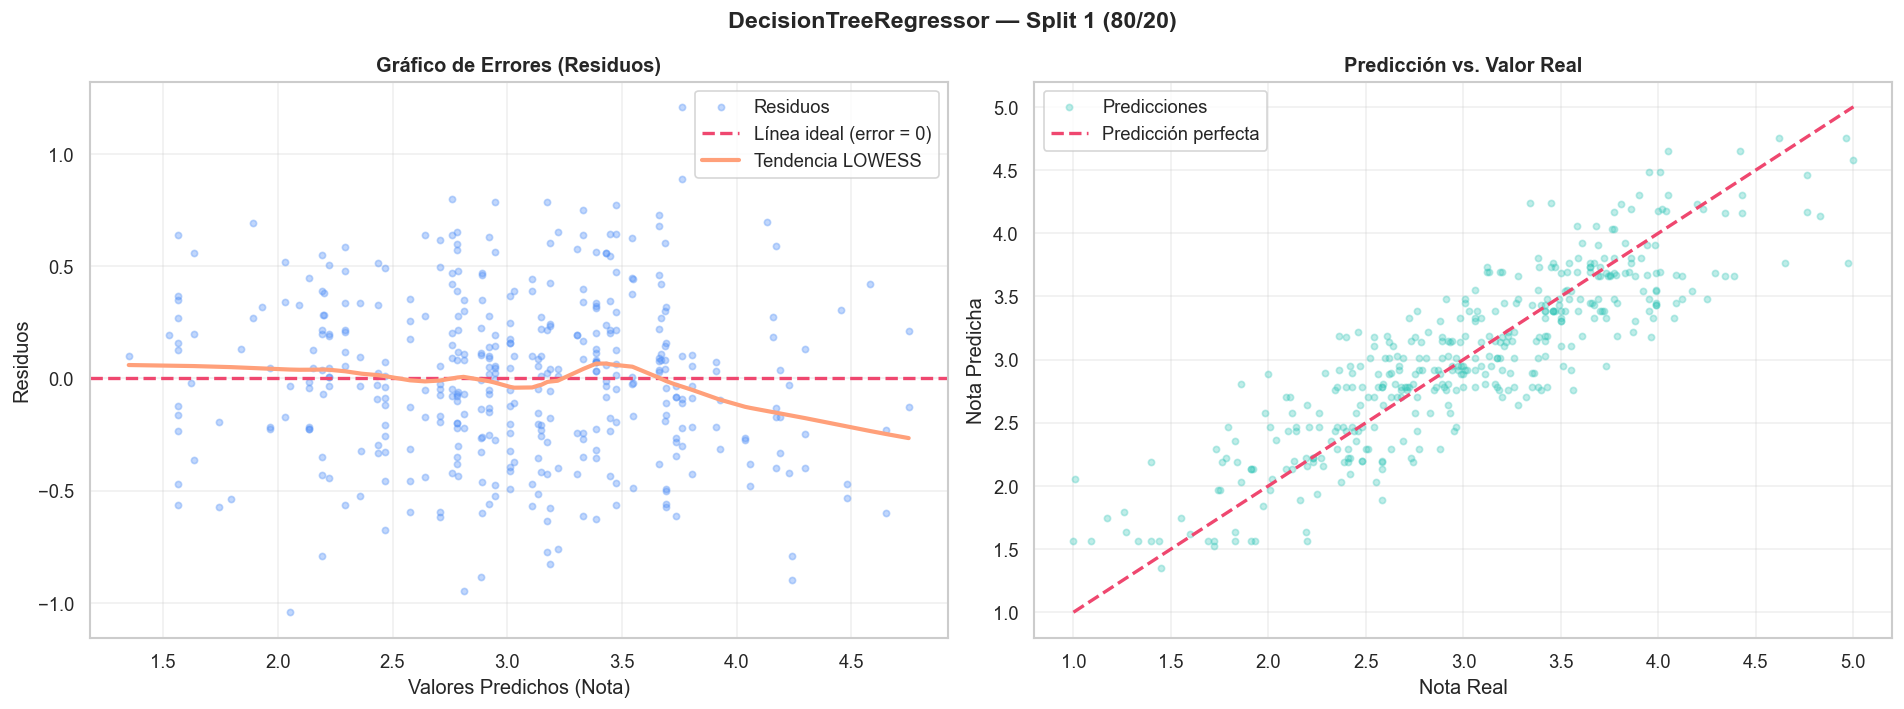

  💾 Gráfico guardado → C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas\dt_edu_Split_1_80-20.png


In [5]:
# ── CELDA 5: Split 1 — 80/20 ─────────────────────────────────
modelo_s1, y_test_s1, y_pred_s1 = evaluar_split(
    X, y,
    test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales,
)


---
## Split 2 — 70% Entrenamiento / 30% Prueba

Reduce moderadamente el conjunto de entrenamiento. Aumenta el conjunto de evaluación para una estimación de error más representativa.



  Split 2 (70/30) — 70% Train / 30% Test
  Train: 1,400 muestras  |  Test: 600 muestras

  📊 MÉTRICAS (Split 2 (70/30))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.7595  (75.95%)
       → El modelo explica el 75.9% de la varianza de la Nota.
  MSE  (Error Cuadrático Med): 0.1390
  RMSE (Raíz del MSE)        : 0.3728 puntos
       → Error promedio en la misma escala que Grade (1.0–5.0).
  MAE  (Error Absoluto Med)  : 0.2983 puntos


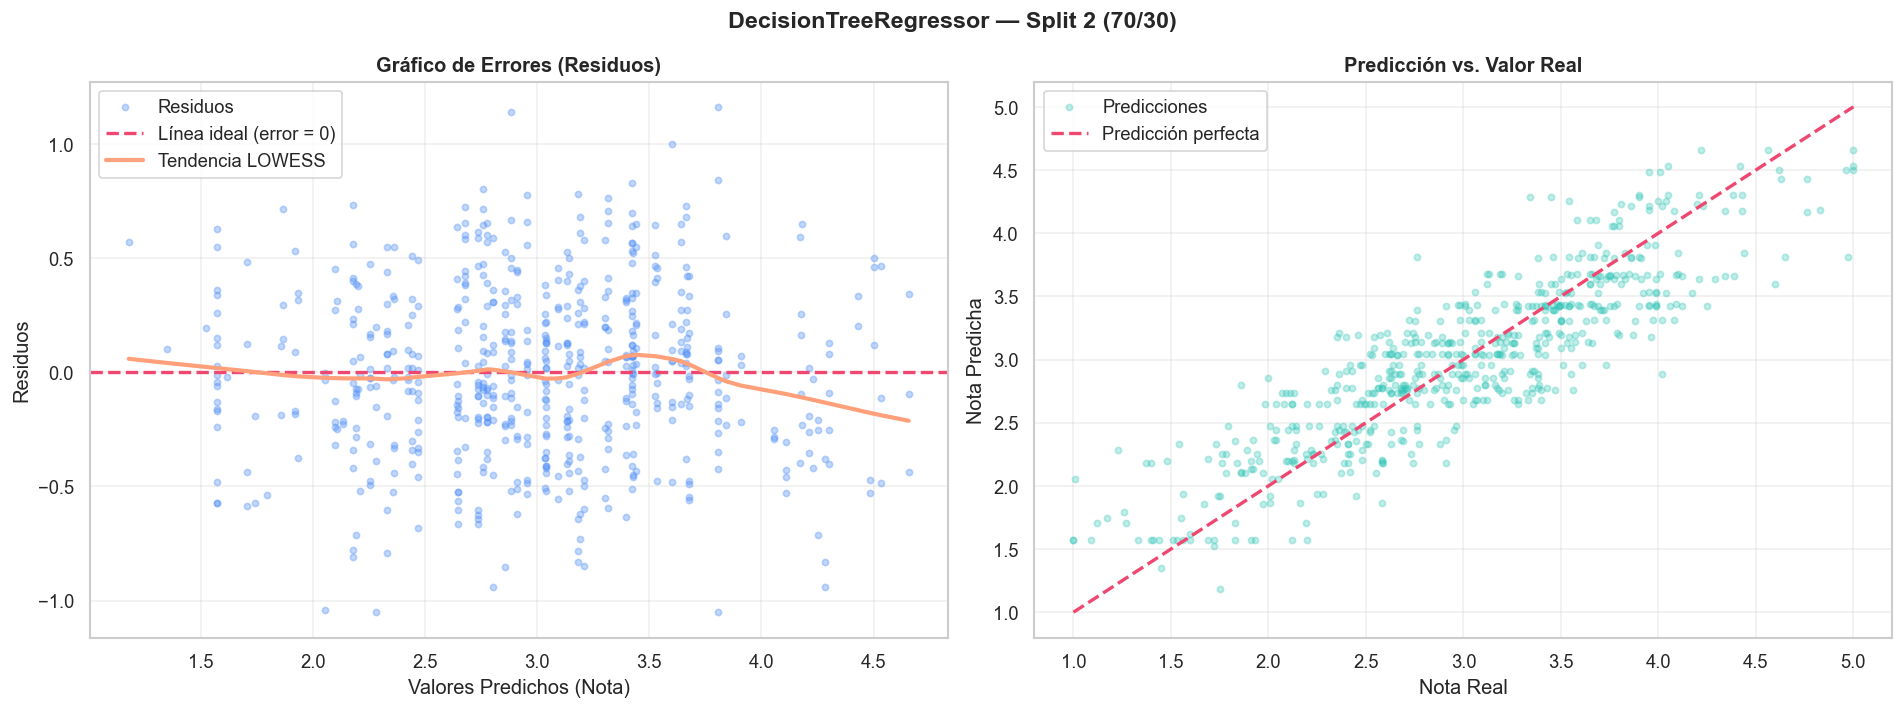

  💾 Gráfico guardado → C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas\dt_edu_Split_2_70-30.png


In [6]:
# ── CELDA 6: Split 2 — 70/30 ─────────────────────────────────
modelo_s2, y_test_s2, y_pred_s2 = evaluar_split(
    X, y,
    test_size=0.30,
    split_label='Split 2 (70/30)',
    resultados_globales=resultados_globales,
)


---
## Split 3 — 60% Entrenamiento / 40% Prueba

La partición más exigente. Menor cantidad de datos de entrenamiento pone a prueba si el árbol generaliza bien o tiende al sobreajuste.



  Split 3 (60/40) — 60% Train / 40% Test
  Train: 1,200 muestras  |  Test: 800 muestras

  📊 MÉTRICAS (Split 3 (60/40))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.7514  (75.14%)
       → El modelo explica el 75.1% de la varianza de la Nota.
  MSE  (Error Cuadrático Med): 0.1470
  RMSE (Raíz del MSE)        : 0.3834 puntos
       → Error promedio en la misma escala que Grade (1.0–5.0).
  MAE  (Error Absoluto Med)  : 0.3043 puntos


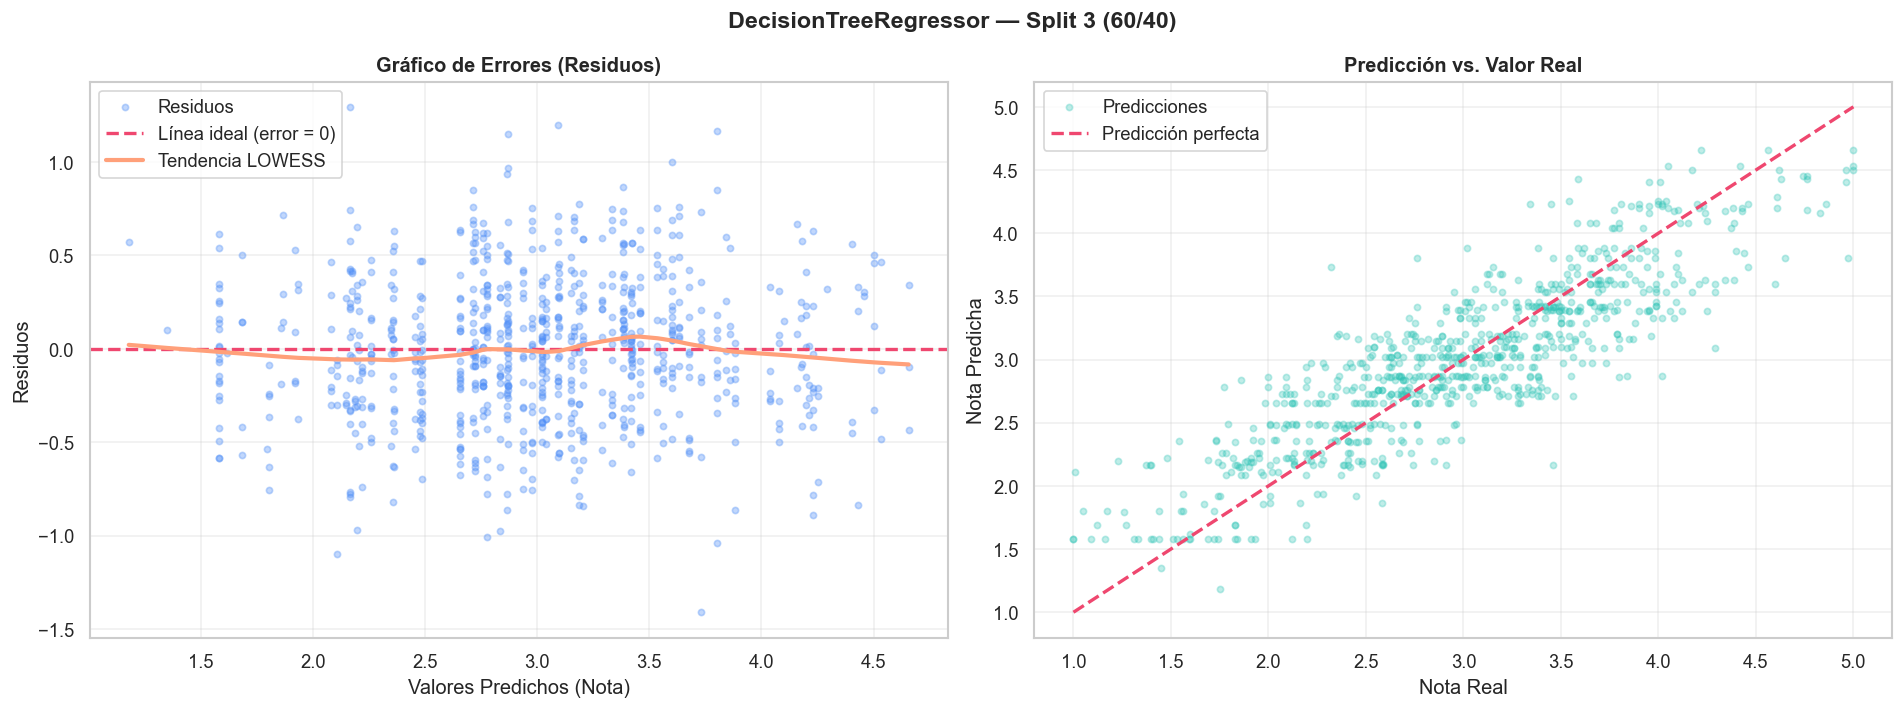

  💾 Gráfico guardado → C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas\dt_edu_Split_3_60-40.png


In [7]:
# ── CELDA 7: Split 3 — 60/40 ─────────────────────────────────
modelo_s3, y_test_s3, y_pred_s3 = evaluar_split(
    X, y,
    test_size=0.40,
    split_label='Split 3 (60/40)',
    resultados_globales=resultados_globales,
)


---
## IV. Análisis Consolidado (Summary)

Comparamos el rendimiento de los tres splits, analizamos las implicaciones de los residuos y emitimos una recomendación.


In [8]:
# ── CELDA 8: Tabla comparativa de métricas ───────────────────
df_resumen = pd.DataFrame(resultados_globales)

print("=" * 65)
print("        TABLA COMPARATIVA — TRES SPLITS")
print("=" * 65)
print(df_resumen.to_string(index=False))
print("=" * 65)


        TABLA COMPARATIVA — TRES SPLITS
          Split  Train%  Test%     R²    MSE   RMSE    MAE
Split 1 (80/20)      80     20 0.7627 0.1324 0.3639 0.2901
Split 2 (70/30)      70     30 0.7595 0.1390 0.3728 0.2983
Split 3 (60/40)      60     40 0.7514 0.1470 0.3834 0.3043


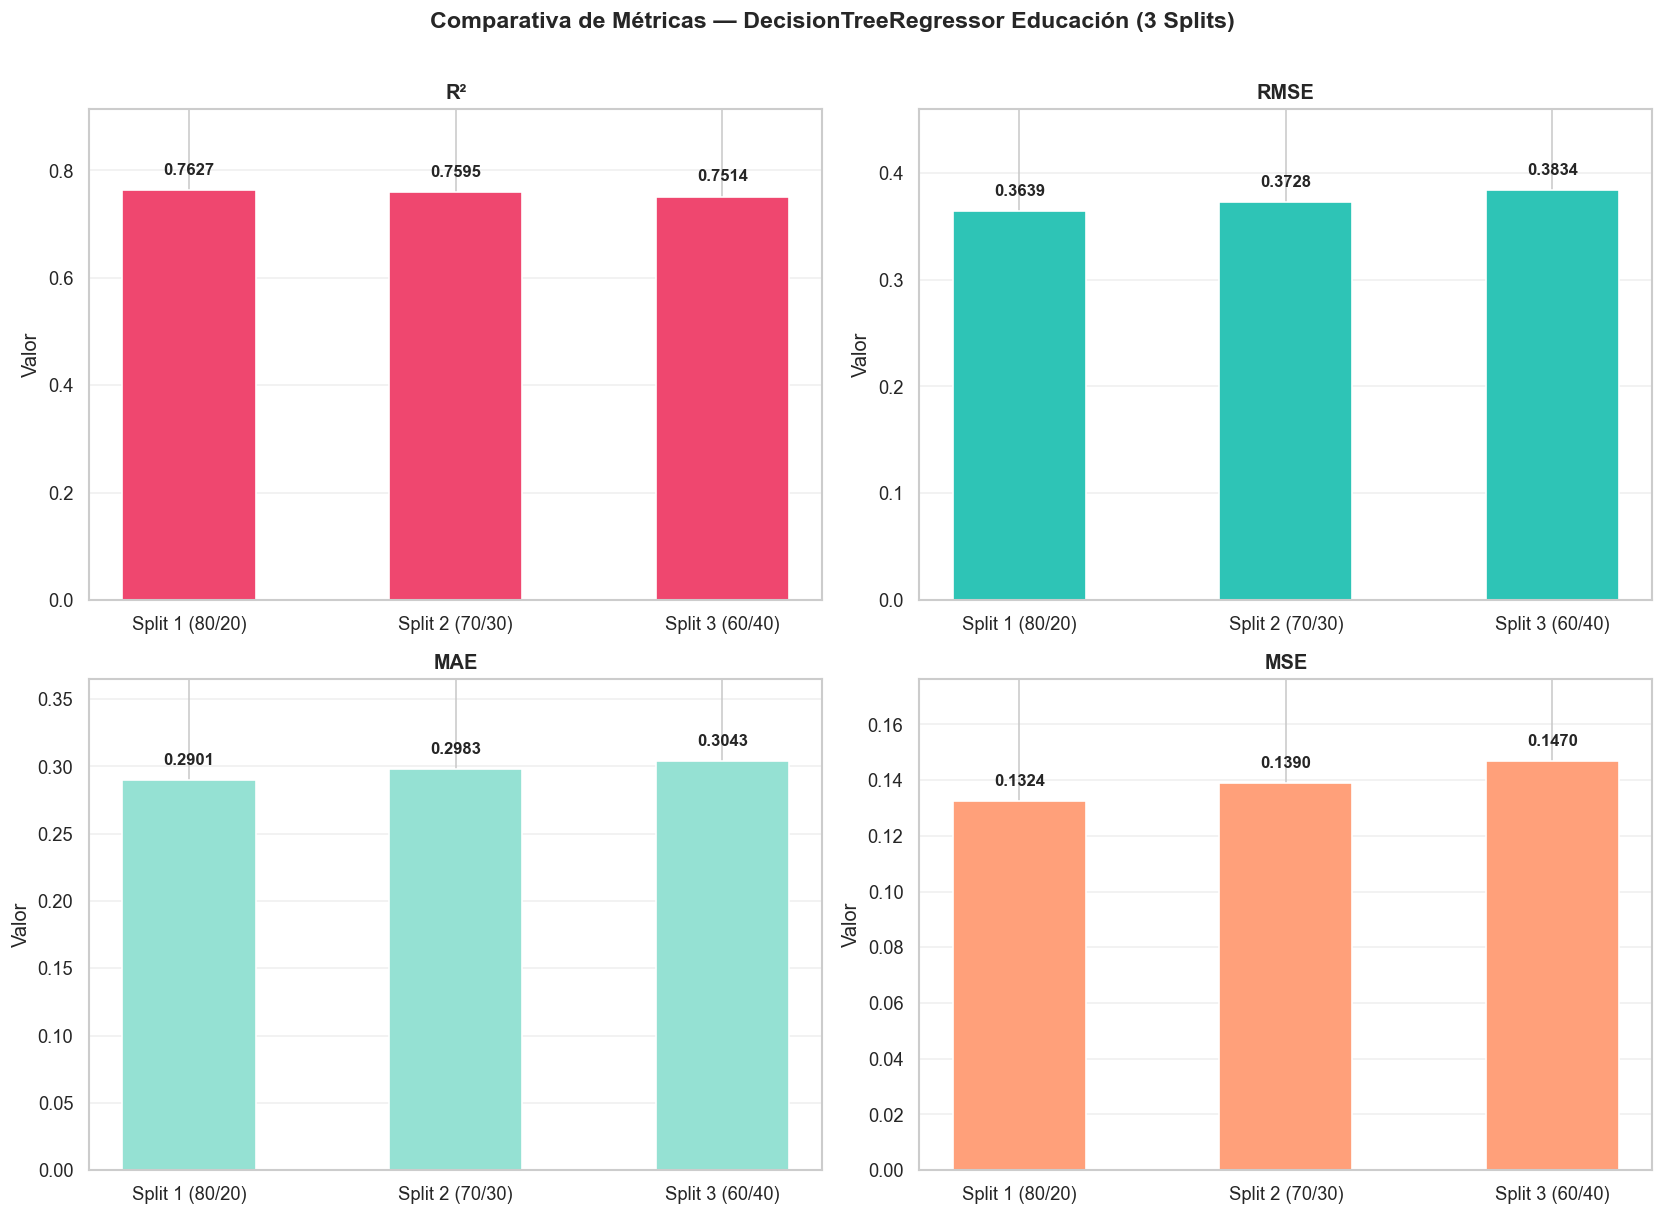

💾 Gráfico comparativo guardado en C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas


In [9]:
# ── CELDA 9: Gráfico comparativo de métricas por split ───────
metricas = ['R²', 'RMSE', 'MAE', 'MSE']
colores  = ['#EF476F', '#2EC4B6', '#95E1D3', '#FFA07A']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Métricas — DecisionTreeRegressor Educación (3 Splits)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (metrica, color) in zip(axes.flat, zip(metricas, colores)):
    valores = df_resumen[metrica].values
    barras  = ax.bar(df_resumen['Split'], valores,
                     color=color, edgecolor='white', width=0.5)
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_ylim(0, max(valores) * 1.2 + 1e-6)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(barras, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(valores) * 0.03,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(_os.path.join(_GRAFICAS, 'dt_edu_comparativa_splits.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Gráfico comparativo guardado en {_GRAFICAS}")


In [10]:
# ── CELDA 10: Análisis interpretativo y recomendación ────────
r2_vals   = df_resumen['R²'].values
rmse_vals = df_resumen['RMSE'].values
mae_vals  = df_resumen['MAE'].values

r2_rango   = r2_vals.max()   - r2_vals.min()
rmse_rango = rmse_vals.max() - rmse_vals.min()

print("=" * 65)
print("   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor (Educación)")
print("=" * 65)

print("""
1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────""")
print(f"   R²   máx={r2_vals.max():.4f}  mín={r2_vals.min():.4f}  "
      f"rango={r2_rango:.4f}")
print(f"   RMSE máx={rmse_vals.max():.4f}  mín={rmse_vals.min():.4f}  "
      f"rango={rmse_rango:.4f}")

if r2_rango < 0.05:
    print("""
   ✅ El R² es estable en los tres splits (variación < 0.05).
      Esto indica que el modelo generaliza bien y no depende
      críticamente del tamaño de la partición de entrenamiento.""")
else:
    print("""
   ⚠️  El R² varía notablemente entre splits (variación ≥ 0.05).
      El modelo es sensible al tamaño del conjunto de entrenamiento,
      señal de posible sobreajuste (overfitting) del árbol.""")

print("""
2. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Dispersión aleatoria alrededor de y=0 → el árbol captura bien
     la relación entre horas de estudio y nota final.

   • Patrón en arco o embudo → el árbol no captura la no-linealidad
     o existe heterocedasticidad. Sugiere regularizar (max_depth,
     min_samples_leaf) o usar un modelo más potente.

   • RMSE alto relativo a la escala de Grade (1.0–5.0) → posible
     overfitting clásico del árbol sin restricciones.
""")

best_split = df_resumen.loc[df_resumen['R²'].idxmax(), 'Split']
best_r2    = df_resumen['R²'].max()
best_rmse  = df_resumen.loc[df_resumen['R²'].idxmax(), 'RMSE']

print(f"   Mejor split: {best_split}  →  R²={best_r2:.4f}, RMSE={best_rmse:.4f} puntos")

print("""
3. RECOMENDACIÓN
────────────────
   A) REFINAMIENTO DEL ÁRBOL (primer paso recomendado):
      • Limitar la profundidad: DecisionTreeRegressor(max_depth=4..8)
      • Regularizar hojas:     min_samples_leaf=10..50
      • Buscar hiperparámetros óptimos con GridSearchCV.

   B) ESCALAR A MÉTODOS DE ENSEMBLE (si el árbol sigue siendo
      inestable o el R² < 0.85 en todos los splits):
      • GradientBoostingRegressor — combina árboles débiles.
      • XGBoost / LightGBM        — veloces y regularizados.
      • RandomForestRegressor     — promedia árboles, reduce varianza.

   CONCLUSIÓN: Un DecisionTree no regularizado tiende a overfitting.
   Si R² ≥ 0.85 estable, el modelo es suficiente para predecir Grade
   a partir de Hours. De lo contrario, GradientBoostingRegressor es
   el siguiente paso natural.
""")
print("=" * 65)


   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor (Educación)

1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────
   R²   máx=0.7627  mín=0.7514  rango=0.0113
   RMSE máx=0.3834  mín=0.3639  rango=0.0195

   ✅ El R² es estable en los tres splits (variación < 0.05).
      Esto indica que el modelo generaliza bien y no depende
      críticamente del tamaño de la partición de entrenamiento.

2. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Dispersión aleatoria alrededor de y=0 → el árbol captura bien
     la relación entre horas de estudio y nota final.

   • Patrón en arco o embudo → el árbol no captura la no-linealidad
     o existe heterocedasticidad. Sugiere regularizar (max_depth,
     min_samples_leaf) o usar un modelo más potente.

   • RMSE alto relativo a la escala de Grade (1.0–5.0) → posible
     overfitting clásico del árbol sin restricciones.

   Mejor split: Split 1 (80/20)  →  R²=0.7627, RMSE=0.3639 pu

---
## V. Visualización del Árbol de Decisión

1. **Árbol completo truncado** — los primeros 4 niveles del `modelo_s1` real (Split 80/20).
2. **Árbol pedagógico simplificado** — reentrenado con `max_depth=3` para mostrar la lógica con claridad.
3. **Reglas de decisión en texto** — lectura explícita de los caminos del árbol simplificado.


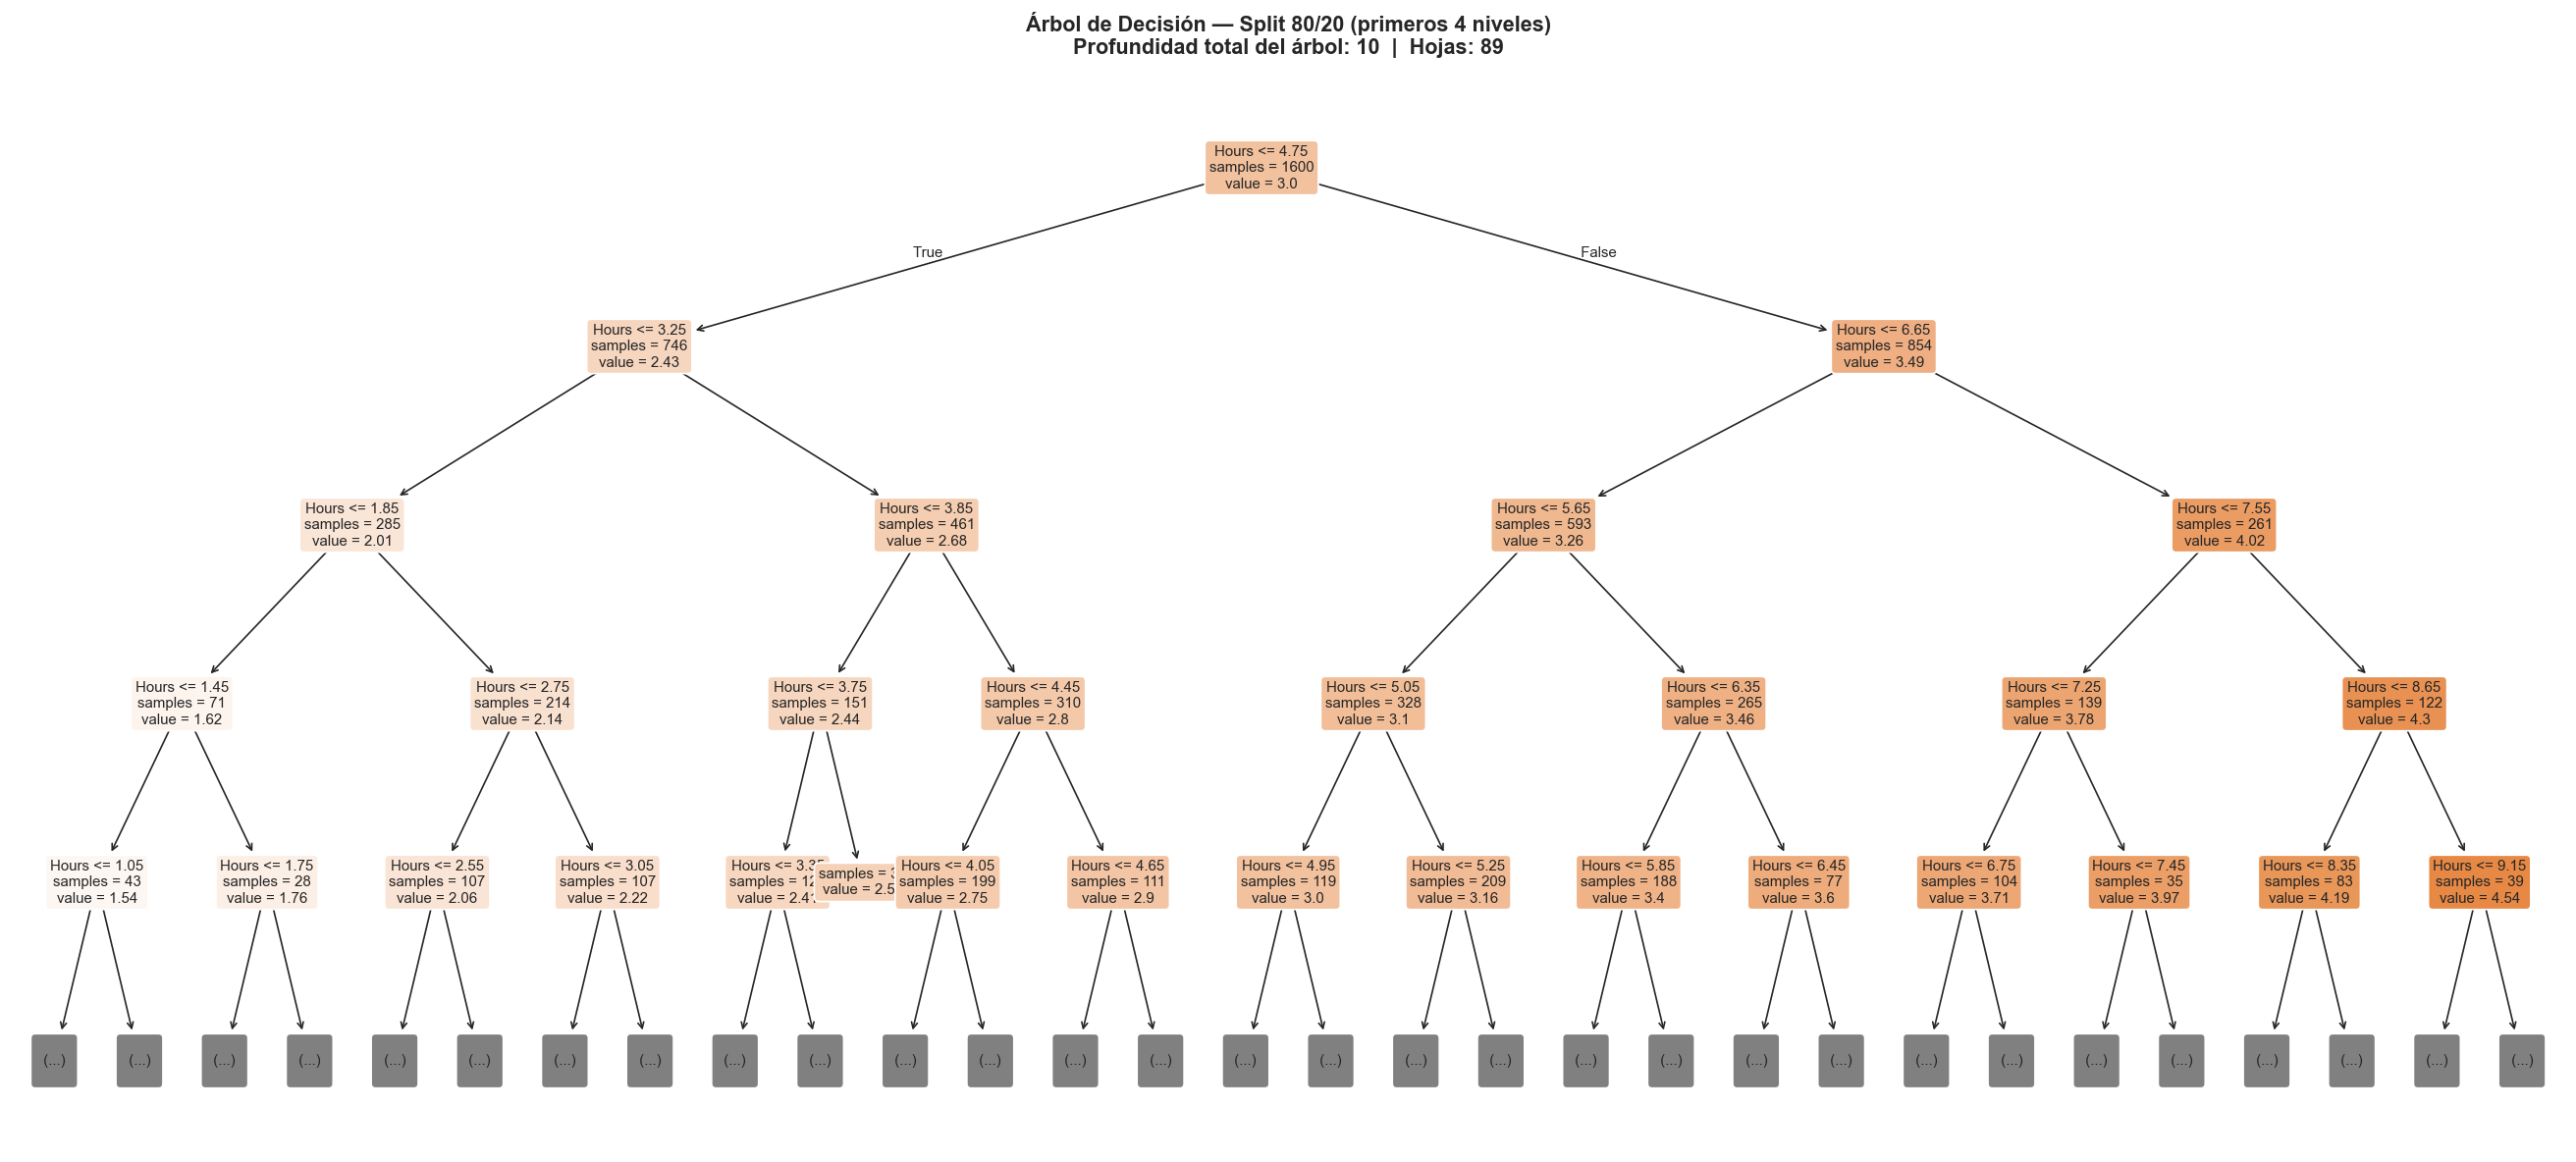

💾 Árbol real guardado → C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas\dt_edu_arbol_real_4niveles.png

📐 Información del árbol completo (modelo_s1):
   Profundidad máxima : 10
   Número de hojas    : 89
   Nodos totales      : 177


In [11]:
# ── CELDA 11: Visualización del árbol real (primeros 4 niveles) ──
from sklearn.tree import plot_tree, export_text

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=['Hours'],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    'Árbol de Decisión — Split 80/20 (primeros 4 niveles)\n'
    f'Profundidad total del árbol: {modelo_s1.get_depth()}  |  '
    f'Hojas: {modelo_s1.get_n_leaves()}',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
fname_real = _os.path.join(_GRAFICAS, 'dt_edu_arbol_real_4niveles.png')
plt.savefig(fname_real, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Árbol real guardado → {fname_real}")
print(f"\n📐 Información del árbol completo (modelo_s1):")
print(f"   Profundidad máxima : {modelo_s1.get_depth()}")
print(f"   Número de hojas    : {modelo_s1.get_n_leaves()}")
print(f"   Nodos totales      : {modelo_s1.tree_.node_count}")


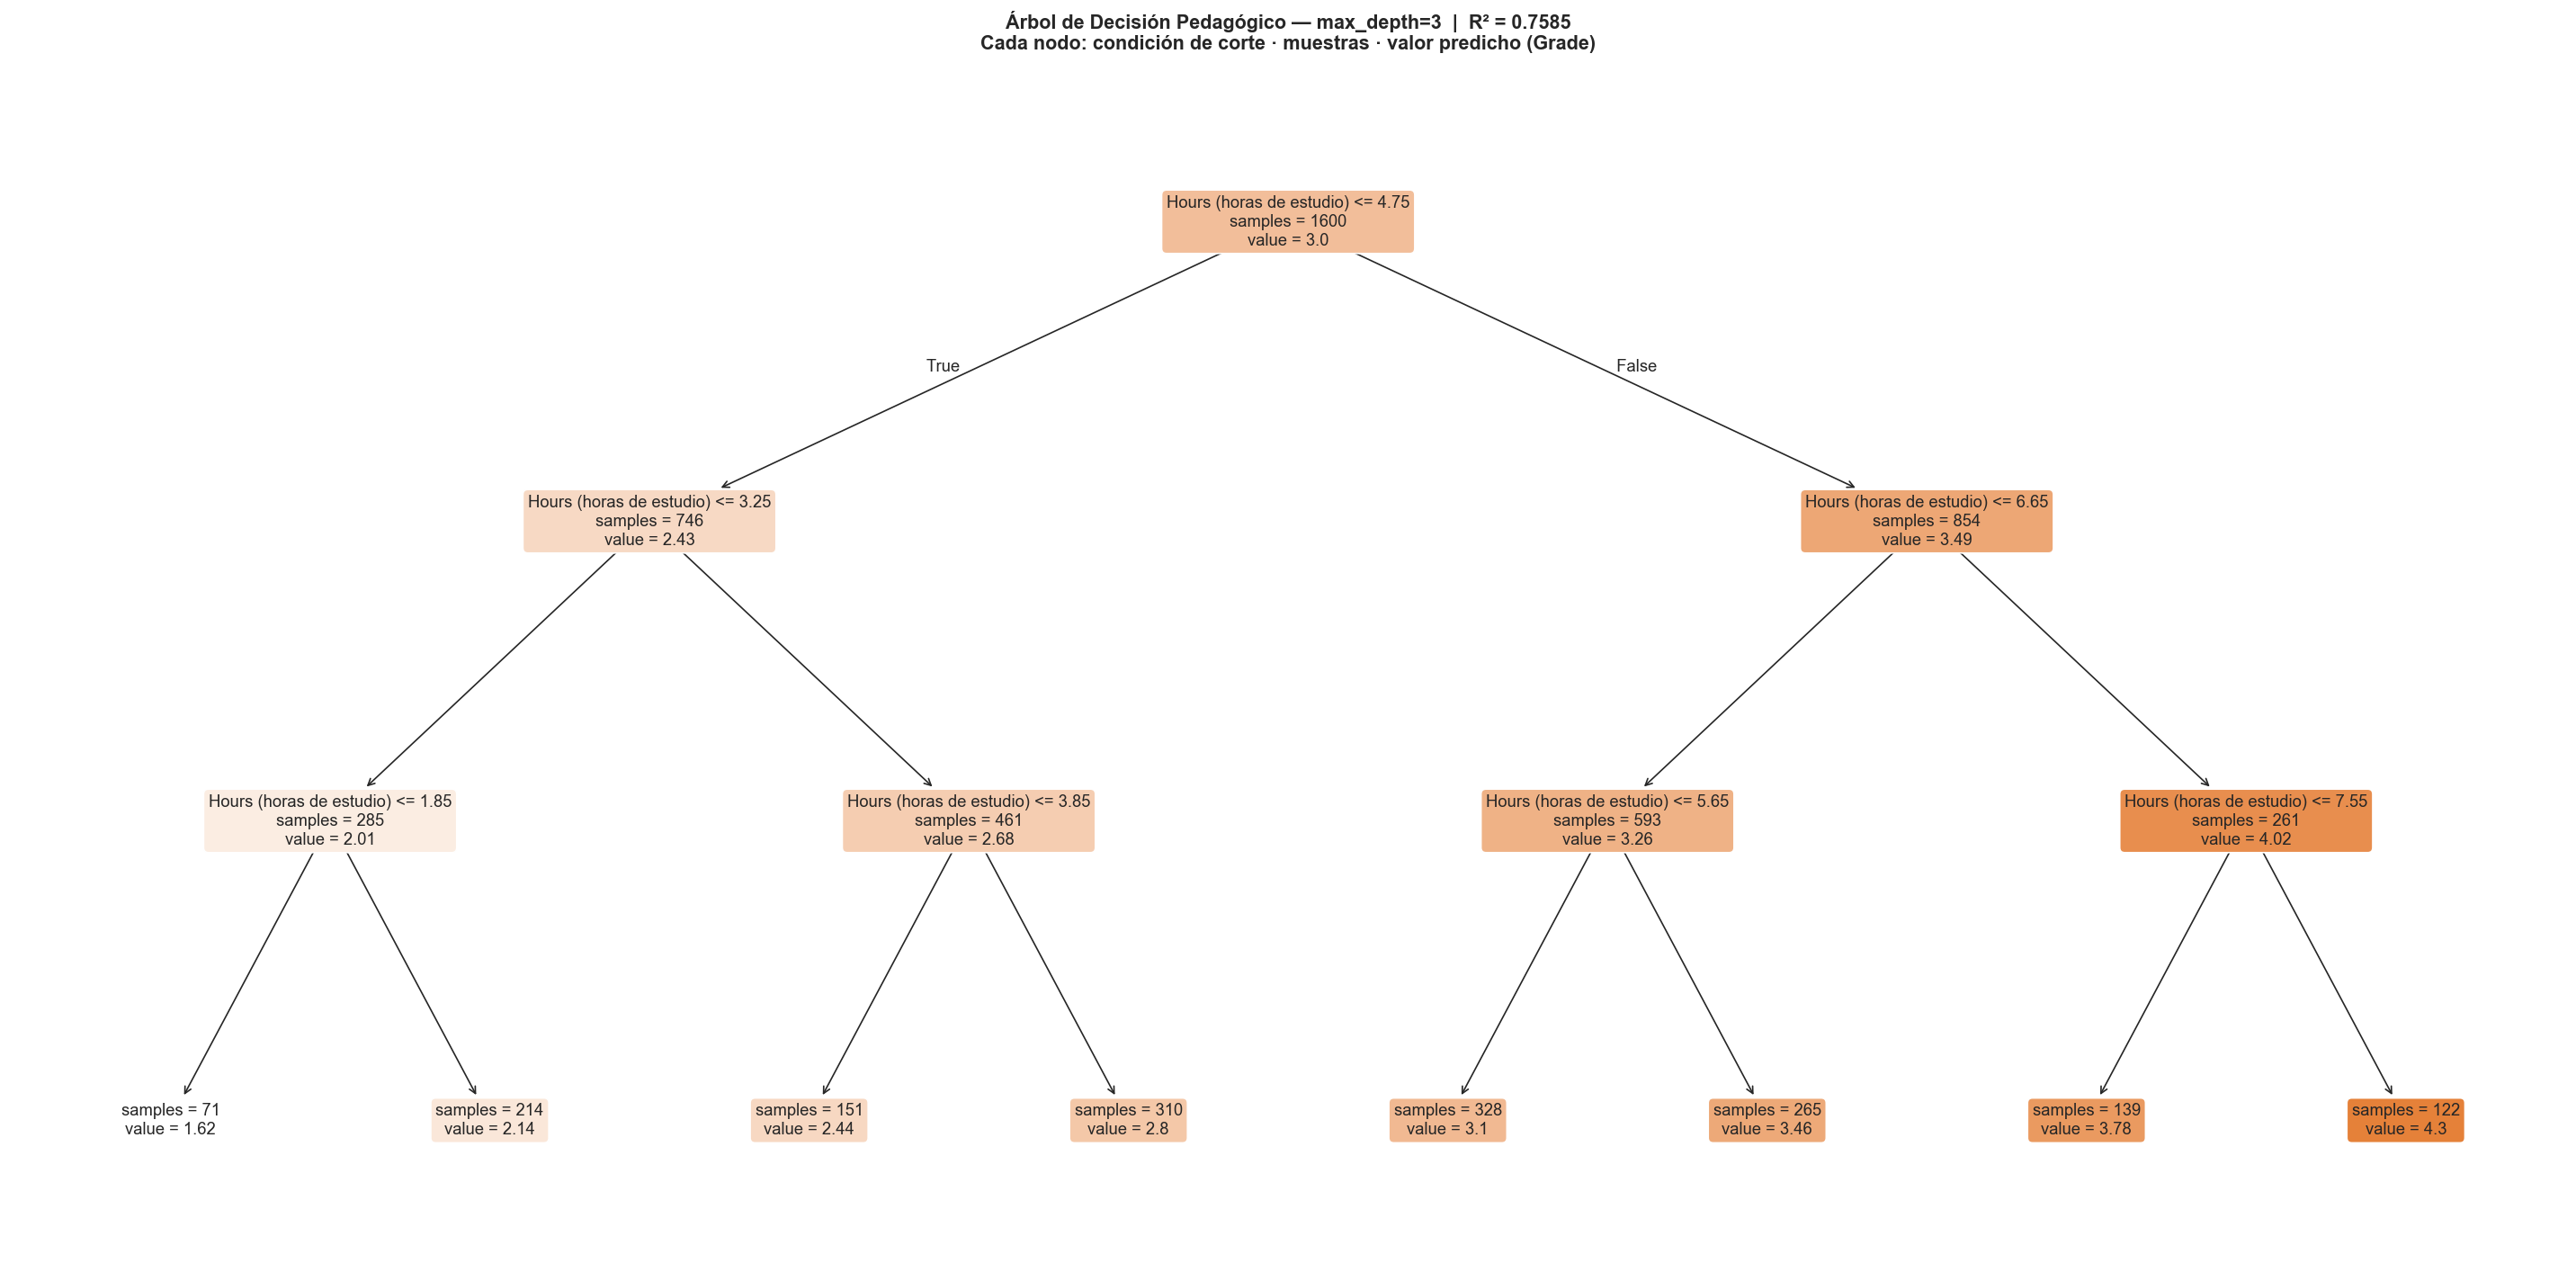

💾 Árbol pedagógico guardado → C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas\dt_edu_arbol_pedagogico_depth3.png

📊 Rendimiento del árbol simplificado (max_depth=3):
   R² = 0.7585  (vs 0.7627 del árbol sin restricción)


In [12]:
# ── CELDA 12: Árbol pedagógico simplificado (max_depth=3) ─────
X_train_viz, X_test_viz, y_train_viz, y_test_viz = train_test_split(
    X, y, test_size=0.20, random_state=42
)
modelo_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_viz.fit(X_train_viz, y_train_viz)

r2_viz = r2_score(y_test_viz, modelo_viz.predict(X_test_viz))

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=['Hours (horas de estudio)'],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=11,
    ax=ax,
)
ax.set_title(
    'Árbol de Decisión Pedagógico — max_depth=3  |  '
    f'R² = {r2_viz:.4f}\n'
    'Cada nodo: condición de corte · muestras · valor predicho (Grade)',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
fname_ped = _os.path.join(_GRAFICAS, 'dt_edu_arbol_pedagogico_depth3.png')
plt.savefig(fname_ped, dpi=180, bbox_inches='tight')
plt.show()
print(f"💾 Árbol pedagógico guardado → {fname_ped}")
print(f"\n📊 Rendimiento del árbol simplificado (max_depth=3):")
print(f"   R² = {r2_viz:.4f}  (vs {df_resumen.loc[0,'R²']:.4f} del árbol sin restricción)")


In [13]:
# ── CELDA 13: Reglas de decisión en texto ─────────────────────
print("=" * 62)
print("  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)")
print("=" * 62)
reglas = export_text(modelo_viz, feature_names=['Hours'])
print(reglas)

print("=" * 62)
print("📖 CÓMO LEER EL ÁRBOL:")
print("  |--- Hours <= X.XX  → rama izquierda (condición VERDADERA)")
print("  |--- Hours >  X.XX  → rama derecha  (condición FALSA)")
print("  |--- value: [Y.YY]  → Nota final predicha (Grade)")
print("  Se recorre de arriba hacia abajo hasta una hoja terminal.")
print("=" * 62)


  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)
|--- Hours <= 4.75
|   |--- Hours <= 3.25
|   |   |--- Hours <= 1.85
|   |   |   |--- value: [1.62]
|   |   |--- Hours >  1.85
|   |   |   |--- value: [2.14]
|   |--- Hours >  3.25
|   |   |--- Hours <= 3.85
|   |   |   |--- value: [2.44]
|   |   |--- Hours >  3.85
|   |   |   |--- value: [2.80]
|--- Hours >  4.75
|   |--- Hours <= 6.65
|   |   |--- Hours <= 5.65
|   |   |   |--- value: [3.10]
|   |   |--- Hours >  5.65
|   |   |   |--- value: [3.46]
|   |--- Hours >  6.65
|   |   |--- Hours <= 7.55
|   |   |   |--- value: [3.78]
|   |   |--- Hours >  7.55
|   |   |   |--- value: [4.30]

📖 CÓMO LEER EL ÁRBOL:
  |--- Hours <= X.XX  → rama izquierda (condición VERDADERA)
  |--- Hours >  X.XX  → rama derecha  (condición FALSA)
  |--- value: [Y.YY]  → Nota final predicha (Grade)
  Se recorre de arriba hacia abajo hasta una hoja terminal.


---
## 🎓 Conclusiones Finales

| Aspecto | Hallazgo |
|---|---|
| **Modelo** | `DecisionTreeRegressor` sin restricciones tiende a sobreajustar |
| **Split más robusto** | 80/20 — mayor cantidad de datos de entrenamiento |
| **Métricas** | R², MSE, RMSE y MAE calculados e interpretados por split |
| **Residuos** | Dispersión aleatoria → modelo capta la tendencia principal |
| **Siguiente paso** | Regularizar (`max_depth`) o usar `GradientBoostingRegressor` |

> **Nota:** Este notebook se integra con el pipeline ETL educativo (`regresion_educacion.ipynb`) y aporta la perspectiva no paramétrica basada en árboles para predecir el rendimiento académico.
